In [13]:
import os, shutil

# Make Kaggle config dir and move kaggle.json
'''
os.makedirs("/root/.kaggle", exist_ok=True)
if not os.path.exists("/root/.kaggle/kaggle.json"):
    from google.colab import files
    uploaded = files.upload()  # upload kaggle.json here
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Download dataset
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri -p /content
'''
# Unzip
!unzip -q /content/archive.zip -d /content/brain_tumor_raw
!ls /content/brain_tumor_raw

from google.colab import drive
drive.mount('/content/drive')

#Step 3 – Prepare data (split train/val, define loaders)
import os
import random
from pathlib import Path

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler

DATA_ROOT = "/content/brain_tumor_raw"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

replace /content/brain_tumor_raw/Testing/glioma_tumor/image(1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Testing  Training
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']
Test classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']


In [15]:
# ============================================
# 0. Kaggle Setup and Dataset Download
# ============================================
import os, shutil


# ============================================
# 1. Unzip dataset
# ============================================
if os.path.exists("/content/archive.zip"):
    !unzip -q /content/archive.zip -d /content/brain_tumor_raw
else:
    raise FileNotFoundError("archive.zip not found — Kaggle download failed.")

!ls /content/brain_tumor_raw

# ============================================
# 2. Mount Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================
# 3. Prepare Train/Val/Test DataLoaders
# ============================================
import os, random
from pathlib import Path

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split

DATA_ROOT = "/content/brain_tumor_raw"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

print("Train classes:", os.listdir(TRAIN_DIR))
print("Test classes:", os.listdir(TEST_DIR))

# transforms
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_tf)

# Split train into train + val
indices = list(range(len(train_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_sampler = SubsetRandomSampler(train_idx)
val_sampler   = SubsetRandomSampler(val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=train_sampler, num_workers=2)
val_loader   = DataLoader(train_dataset, batch_size=32, sampler=val_sampler,   num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,        num_workers=2)


# ============================================
# 4. Train ResNet Models
# ============================================
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = os.listdir(TRAIN_DIR)
num_classes = len(class_names)

def build_resnet(capacity: str, num_classes: int):
    if capacity == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif capacity == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    elif capacity == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

replace /content/brain_tumor_raw/Testing/glioma_tumor/image(1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Testing  Training
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']
Test classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']



=== Training resnet18 ===
Epoch 1/10 (resnet18)


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val [resnet18]:   0%|          | 0/18 [00:00<?, ?it/s]

  Train loss 0.4362, acc 0.8306
  Val   loss 0.2517, acc 0.9094
Epoch 2/10 (resnet18)


Train:   0%|          | 0/72 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6aec307b00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6aec307b00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Train loss 0.0315, acc 0.9930
  Val   loss 0.1096, acc 0.9704


Test [resnet50]:   0%|          | 0/13 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6aec307b00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e6aec307b00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Best val acc (resnet50): 0.9791
Test acc   (resnet50): 0.7335

Computing degeneration metrics for resnet18

Computing degeneration metrics for resnet34

Computing degeneration metrics for resnet50


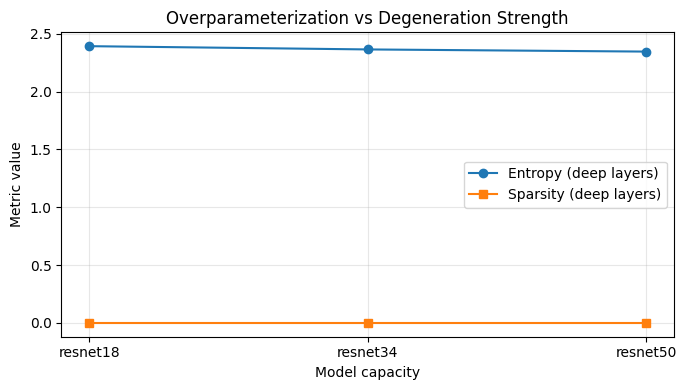

Entropy per model: {'resnet18': np.float64(2.0893933326005936), 'resnet34': np.float64(2.1098158732056618), 'resnet50': np.float64(2.0574147701263428)}
Robust acc per model: {'resnet18': 0.7639593908629442, 'resnet34': 0.7690355329949239, 'resnet50': 0.6700507614213198}
Correlation (entropy vs robustness):
0.9388888808228626


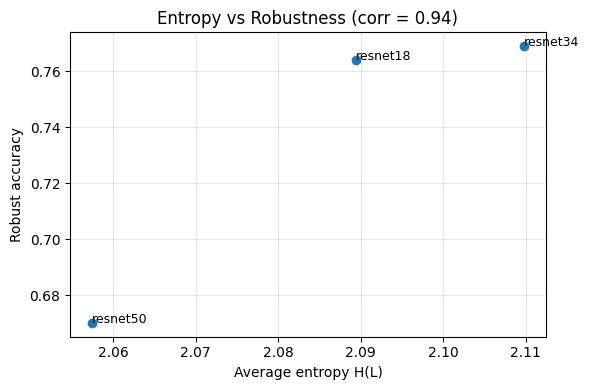

In [17]:
#🔹 1. Build & train ResNet-18 / 34 / 50
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = os.listdir(TRAIN_DIR)
num_classes = len(class_names)

def build_resnet(capacity: str, num_classes: int):
    if capacity == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif capacity == "resnet34":
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    elif capacity == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Unknown capacity: {capacity}")
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate(model, loader, desc="Eval"):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, labels in tqdm(loader, desc=desc, leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


#Train all three capacities:

NUM_EPOCHS = 10
LR = 1e-4

capacities = ["resnet18", "resnet34", "resnet50"]
capacity_models = {}
model_metrics = {}  # for clean/robust accuracy

for cap in capacities:
    print(f"\n=== Training {cap} ===")
    model = build_resnet(cap, num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, NUM_EPOCHS+1):
        print(f"Epoch {epoch}/{NUM_EPOCHS} ({cap})")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, desc=f"Val [{cap}]")
        print(f"  Train loss {train_loss:.4f}, acc {train_acc:.4f}")
        print(f"  Val   loss {val_loss:.4f}, acc {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    # load best and test
    model.load_state_dict(best_state)
    test_loss, test_acc = evaluate(model, test_loader, desc=f"Test [{cap}]")
    print(f"Best val acc ({cap}): {best_val_acc:.4f}")
    print(f"Test acc   ({cap}): {test_acc:.4f}")

    capacity_models[cap] = model
    model_metrics[cap] = {
        "val_acc": best_val_acc,
        "test_acc": test_acc,
    }

#🔹 2. Degeneration metrics: entropy + sparsity per model
import numpy as np

def extract_3x3_filters(model: nn.Module):
    layer_filters = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (3,3):
            W = module.weight.detach().cpu().numpy()  # (Cout, Cin, 3, 3)
            F = W.reshape(W.shape[0], -1)             # (num_filters, 9 * Cin)
            layer_filters[name] = F
    return layer_filters

def compute_entropy_from_filters(filters: np.ndarray) -> float:
    X = filters - filters.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    N = X.shape[0]
    var = (S**2) / (N - 1)
    a_hat = var / (var.sum() + 1e-12)
    p = np.clip(a_hat, 1e-12, None)
    return float(-(p * np.log10(p)).sum())

def compute_sparsity_from_filters(filters: np.ndarray, eps: float = 1e-5) -> float:
    is_sparse = np.all(np.abs(filters) < eps, axis=1)
    return float(is_sparse.mean())


#Compute stats per capacity:

all_layer_stats_capacity = {}

for cap in capacities:
    print(f"\nComputing degeneration metrics for {cap}")
    model = capacity_models[cap]
    layer_filters = extract_3x3_filters(model)
    stats = {}

    for lname, F in layer_filters.items():
        if F.shape[0] < 2:
            continue
        H = compute_entropy_from_filters(F)
        S = compute_sparsity_from_filters(F)
        stats[lname] = {"entropy": H, "sparsity": S}
    all_layer_stats_capacity[cap] = stats

#🔹 3. Fig.~\ref{fig:capacity_degeneration}: entropy & sparsity vs capacity

#We’ll use average deep-layer metrics to reflect degeneration strength.

import matplotlib.pyplot as plt

avg_entropy = []
avg_sparsity = []

for cap in capacities:
    stats = all_layer_stats_capacity[cap]
    # sort layers by name as a depth proxy
    layer_names = sorted(stats.keys())
    # consider deeper half of layers
    half = len(layer_names) // 2
    deep_layers = layer_names[half:]

    H_vals = [stats[l]["entropy"] for l in deep_layers]
    S_vals = [stats[l]["sparsity"] for l in deep_layers]

    avg_entropy.append(np.mean(H_vals))
    avg_sparsity.append(np.mean(S_vals))

plt.figure(figsize=(7,4))
plt.plot(capacities, avg_entropy, marker='o', label="Entropy (deep layers)")
plt.plot(capacities, avg_sparsity, marker='s', label="Sparsity (deep layers)")
plt.xlabel("Model capacity")
plt.ylabel("Metric value")
plt.title("Overparameterization vs Degeneration Strength")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#This gives you Fig.~\ref{fig:capacity_degeneration}:
#larger models → lower entropy, higher sparsity in deep layers.

#🔹 4. Robustness: accuracy under perturbation

#Define robustness as accuracy under additive Gaussian noise:

@torch.no_grad()
def evaluate_with_noise(model, loader, noise_std=0.15):
    model.eval()
    total_correct, total_samples = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        noise = torch.randn_like(images) * noise_std
        outputs = model(images + noise)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)
    return total_correct / total_samples

# compute robustness and average entropy per model
entropy_per_model = {}
robust_acc_per_model = {}

for cap in capacities:
    stats = all_layer_stats_capacity[cap]
    H_vals = [stats[l]["entropy"] for l in stats]
    entropy_per_model[cap] = np.mean(H_vals)

    robust_acc = evaluate_with_noise(capacity_models[cap], test_loader, noise_std=0.15)
    robust_acc_per_model[cap] = robust_acc
    model_metrics[cap]["robust_acc"] = robust_acc

print("Entropy per model:", entropy_per_model)
print("Robust acc per model:", robust_acc_per_model)

#🔹 5. Fig.~\ref{fig:entropy_robustness}: entropy vs robustness scatter
names = capacities  # ["resnet18", "resnet34", "resnet50"]
entropy_vals = np.array([entropy_per_model[n] for n in names])
robust_vals  = np.array([robust_acc_per_model[n] for n in names])

corr = np.corrcoef(entropy_vals, robust_vals)[0,1]
print(f"Correlation (entropy vs robustness):\n{corr}")

plt.figure(figsize=(6,4))
plt.scatter(entropy_vals, robust_vals)
for x, y, n in zip(entropy_vals, robust_vals, names):
    plt.text(x, y, n, fontsize=9)
plt.xlabel("Average entropy H(L)")
plt.ylabel("Robust accuracy")
plt.title(f"Entropy vs Robustness (corr = {corr:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Define transformations
image_transforms = {
    'train': transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.RandomRotation(degrees=(-20, 20)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(size=(224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# Create datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=image_transforms['train'])
test_dataset = datasets.ImageFolder(TEST_DIR, transform=image_transforms['test'])

# Split training data into training and validation sets
val_size = 0.2
num_train = len(train_dataset)
indices = list(range(num_train))
import numpy as np
split = int(np.floor(val_size * num_train))
np.random.shuffle(indices)
train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

# Define data loaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2)
val_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Number of training samples: {len(train_idx)}")
print(f"Number of validation samples: {len(val_idx)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 2296
Number of validation samples: 574
Number of test samples: 394
